 # Performance Metrics Analysis for Salary Prediction Models

 This notebook provides comprehensive performance analysis for Linear Regression and Random Forest models

 with corrected MAPE calculation and all original visualizations

 ## Import Libraries

In [89]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score, 
    explained_variance_score
)
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


 ## Load Data and Models

In [90]:
# Load the dataset 
from dataset.load import load_df

# Load data and create train-test split 
df = load_df()
train = df.sample(frac=0.95, random_state=42)
test = df.drop(train.index)

X_train = train.drop(["Salary"], axis=1)
y_train = train["Salary"].values
X_test = test.drop(["Salary"], axis=1)
y_test = test["Salary"].values

print(f"Test set size: {len(y_test)} samples")
print(f"Salary range in test set: ${y_test.min():,.0f} - ${y_test.max():,.0f}")


Test set size: 698 samples
Salary range in test set: $1 - $300,000


In [91]:
# Load trained models
try:
    lr_pipeline = joblib.load("linear_regression_pipeline.joblib")
    rf_pipeline = joblib.load("best_model_original_rf.joblib")
    print("Models loaded successfully!")
except FileNotFoundError as e:
    print(f"Model file not found: {e}")
    print("Please make sure you have run the training script first.")


Models loaded successfully!


 ## Generate Predictions

In [92]:
# Generate predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

print("Predictions generated successfully!")
print(f"Linear Regression predictions range: ${y_pred_lr.min():,.0f} - ${y_pred_lr.max():,.0f}")
print(f"Random Forest predictions range: ${y_pred_rf.min():,.0f} - ${y_pred_rf.max():,.0f}")


Predictions generated successfully!
Linear Regression predictions range: $-8,178 - $211,690
Random Forest predictions range: $9,476 - $204,933


 ## Comprehensive Performance Metrics (CORRECTED)

In [93]:
def calculate_comprehensive_metrics(y_true, y_pred, model_name):
    """
    Calculate comprehensive performance metrics for regression models with robust MAPE alternatives
    """
    # Calculate individual percentage errors
    individual_errors = np.abs((y_true - y_pred) / y_true) * 100
    
    # Use Median APE 
    median_ape = np.median(individual_errors)
    
    # Calculate MAPE only for reasonable salary ranges (> $15K to avoid extreme percentages)
    reasonable_salary_mask = y_true > 15000
    if np.sum(reasonable_salary_mask) > 0:
        filtered_mape = np.mean(individual_errors[reasonable_salary_mask])
    else:
        filtered_mape = np.inf
    
    # Calculate what percentage of predictions are within reasonable error 
    within_20_pct = (individual_errors <= 20).sum() / len(individual_errors) * 100
    within_30_pct = (individual_errors <= 30).sum() / len(individual_errors) * 100
    
    metrics = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'Median APE (%)': median_ape, 
        'MAPE >$15K (%)': filtered_mape,  # MAPE for salaries > $15K only
        'Within 20% (%)': within_20_pct,  # Percentage of predictions within 20% error
        'Within 30% (%)': within_30_pct,  # Percentage of predictions within 30% error
        'Explained Variance': explained_variance_score(y_true, y_pred),
        'Max Error': np.max(np.abs(y_true - y_pred)),
        'Mean Error': np.mean(y_true - y_pred),
        'Std Error': np.std(y_true - y_pred),
        'Pearson Correlation': pearsonr(y_true, y_pred)[0]
    }
    return metrics

# Calculate metrics for both models
lr_metrics = calculate_comprehensive_metrics(y_test, y_pred_lr, 'Linear Regression')
rf_metrics = calculate_comprehensive_metrics(y_test, y_pred_rf, 'Random Forest')

# Create comparison dataframe
metrics_df = pd.DataFrame([lr_metrics, rf_metrics])
metrics_df = metrics_df.round(3)

print("\n" + "="*80)
print("COMPREHENSIVE PERFORMANCE METRICS COMPARISON")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)



COMPREHENSIVE PERFORMANCE METRICS COMPARISON
            Model      RMSE       MAE    R²  Median APE (%)  MAPE >$15K (%)  Within 20% (%)  Within 30% (%)  Explained Variance  Max Error  Mean Error  Std Error  Pearson Correlation
Linear Regression 47134.374 36416.951 0.369          40.323          49.982          26.074          38.825               0.369 230134.146    -259.525  47133.659                0.608
    Random Forest 32861.217 22906.022 0.693          23.618          31.074          42.837          59.885               0.694 263284.739    1227.531  32838.281                0.837


 ## Detailed Performance Analysis

In [94]:
# Performance improvement analysis
print("\n" + "="*60)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*60)

rmse_improvement = ((lr_metrics['RMSE'] - rf_metrics['RMSE']) / lr_metrics['RMSE']) * 100
mae_improvement = ((lr_metrics['MAE'] - rf_metrics['MAE']) / lr_metrics['MAE']) * 100
r2_improvement = ((rf_metrics['R²'] - lr_metrics['R²']) / lr_metrics['R²']) * 100

# Use Median APE for comparison
median_ape_improvement = ((lr_metrics['Median APE (%)'] - rf_metrics['Median APE (%)']) / lr_metrics['Median APE (%)']) * 100

print(f"Random Forest vs Linear Regression:")
print(f"• RMSE improved by: {rmse_improvement:.1f}%")
print(f"• MAE improved by: {mae_improvement:.1f}%")
print(f"• R² improved by: {r2_improvement:.1f}%")
print(f"• Median APE improved by: {median_ape_improvement:.1f}%")

# Error analysis
lr_errors = y_test - y_pred_lr
rf_errors = y_test - y_pred_rf

print(f"\nError Distribution Analysis:")
print(f"Linear Regression - Mean Error: ${lr_metrics['Mean Error']:,.0f}, Std: ${lr_metrics['Std Error']:,.0f}")
print(f"Random Forest - Mean Error: ${rf_metrics['Mean Error']:,.0f}, Std: ${rf_metrics['Std Error']:,.0f}")

print(f"\nPrediction Accuracy:")
print(f"Random Forest - {rf_metrics['Within 20% (%)']:.1f}% of predictions within 20% error")
print(f"Random Forest - {rf_metrics['Within 30% (%)']:.1f}% of predictions within 30% error")
print("="*60)



PERFORMANCE IMPROVEMENT ANALYSIS
Random Forest vs Linear Regression:
• RMSE improved by: 30.3%
• MAE improved by: 37.1%
• R² improved by: 87.8%
• Median APE improved by: 41.4%

Error Distribution Analysis:
Linear Regression - Mean Error: $-260, Std: $47,134
Random Forest - Mean Error: $1,228, Std: $32,838

Prediction Accuracy:
Random Forest - 42.8% of predictions within 20% error
Random Forest - 59.9% of predictions within 30% error


 ## Visualization: Performance Metrics Comparison

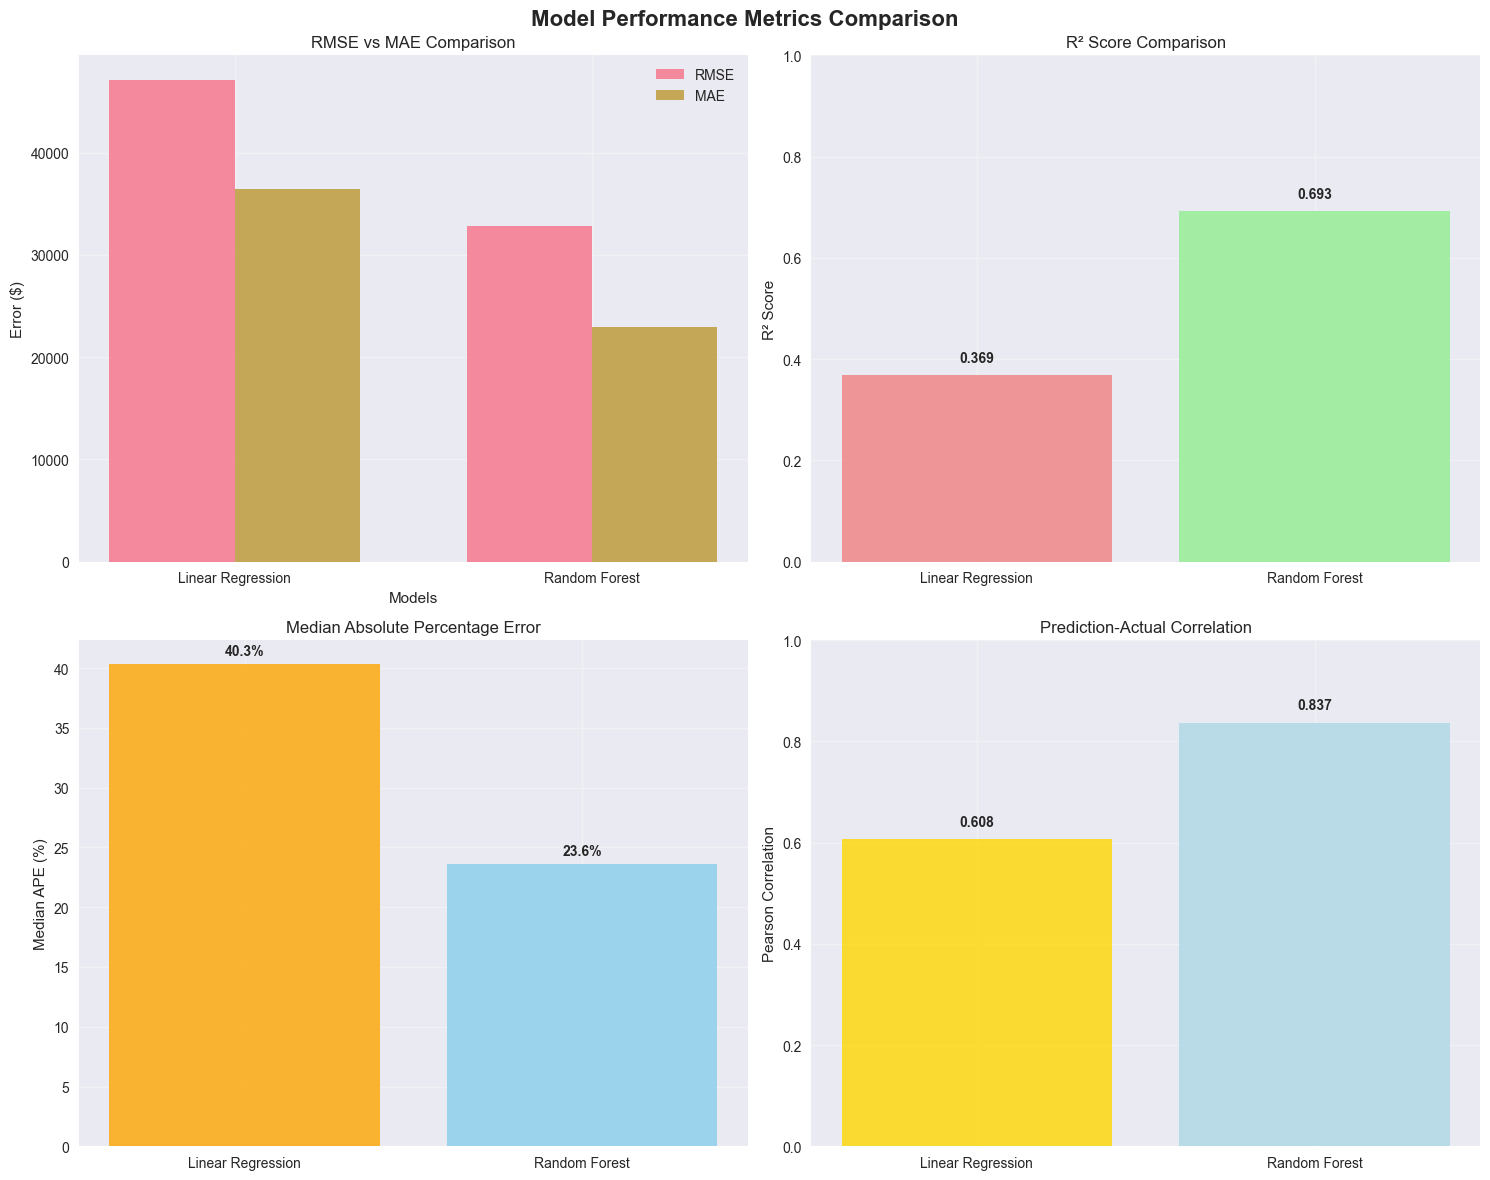

In [95]:
# Create a comprehensive metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')

# RMSE and MAE Comparison
models = ['Linear Regression', 'Random Forest']
rmse_values = [lr_metrics['RMSE'], rf_metrics['RMSE']]
mae_values = [lr_metrics['MAE'], rf_metrics['MAE']]

x = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x - width/2, rmse_values, width, label='RMSE', alpha=0.8)
axes[0, 0].bar(x + width/2, mae_values, width, label='MAE', alpha=0.8)
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('Error ($)')
axes[0, 0].set_title('RMSE vs MAE Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# R² Score Comparison
r2_values = [lr_metrics['R²'], rf_metrics['R²']]
colors = ['lightcoral', 'lightgreen']
axes[0, 1].bar(models, r2_values, color=colors, alpha=0.8)
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('R² Score Comparison')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(r2_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Median APE Comparison
median_ape_values = [lr_metrics['Median APE (%)'], rf_metrics['Median APE (%)']]
axes[1, 0].bar(models, median_ape_values, color=['orange', 'skyblue'], alpha=0.8)
axes[1, 0].set_ylabel('Median APE (%)')
axes[1, 0].set_title('Median Absolute Percentage Error')
axes[1, 0].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(median_ape_values):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# Correlation Comparison
corr_values = [lr_metrics['Pearson Correlation'], rf_metrics['Pearson Correlation']]
axes[1, 1].bar(models, corr_values, color=['gold', 'lightblue'], alpha=0.8)
axes[1, 1].set_ylabel('Pearson Correlation')
axes[1, 1].set_title('Prediction-Actual Correlation')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(corr_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


 ## Prediction vs Actual Value Analysis

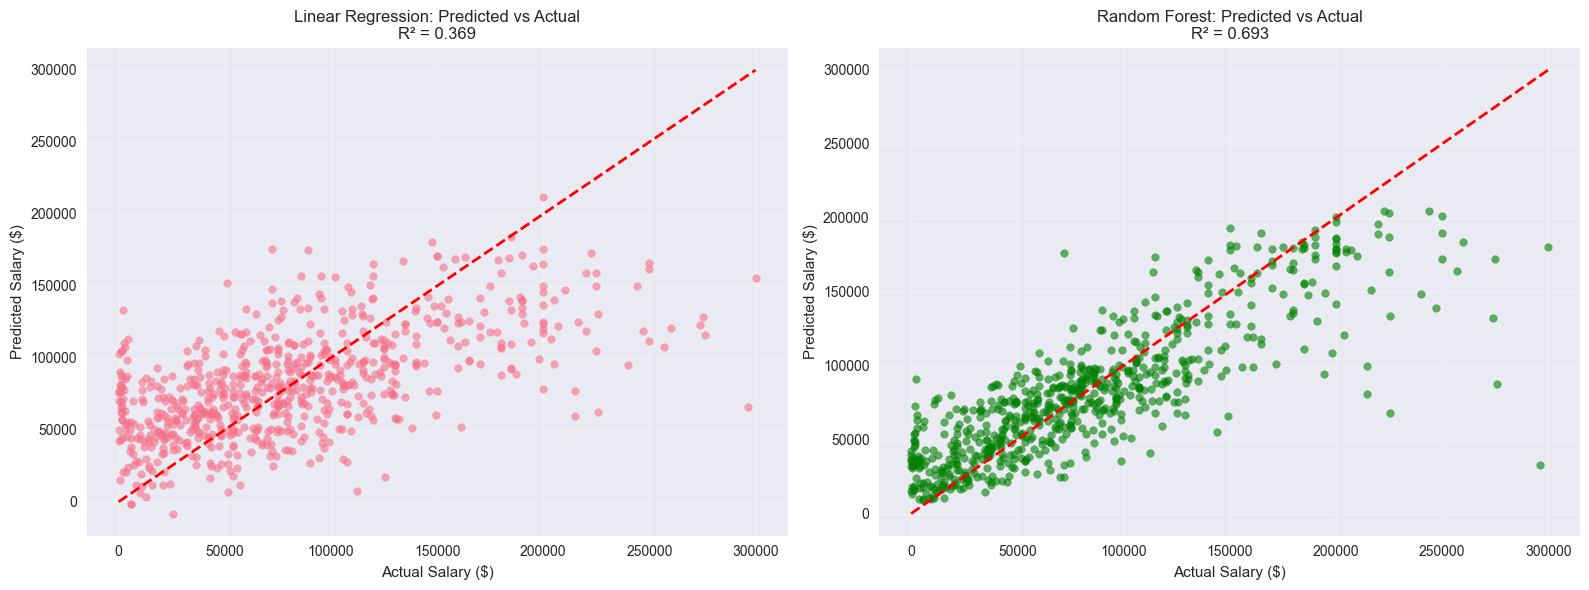

In [96]:
# Scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression
ax1.scatter(y_test, y_pred_lr, alpha=0.6, s=30)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Salary ($)')
ax1.set_ylabel('Predicted Salary ($)')
ax1.set_title(f'Linear Regression: Predicted vs Actual\nR² = {lr_metrics["R²"]:.3f}')
ax1.grid(True, alpha=0.3)

# Random Forest
ax2.scatter(y_test, y_pred_rf, alpha=0.6, s=30, color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Salary ($)')
ax2.set_ylabel('Predicted Salary ($)')
ax2.set_title(f'Random Forest: Predicted vs Actual\nR² = {rf_metrics["R²"]:.3f}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 ## Residual Analysis

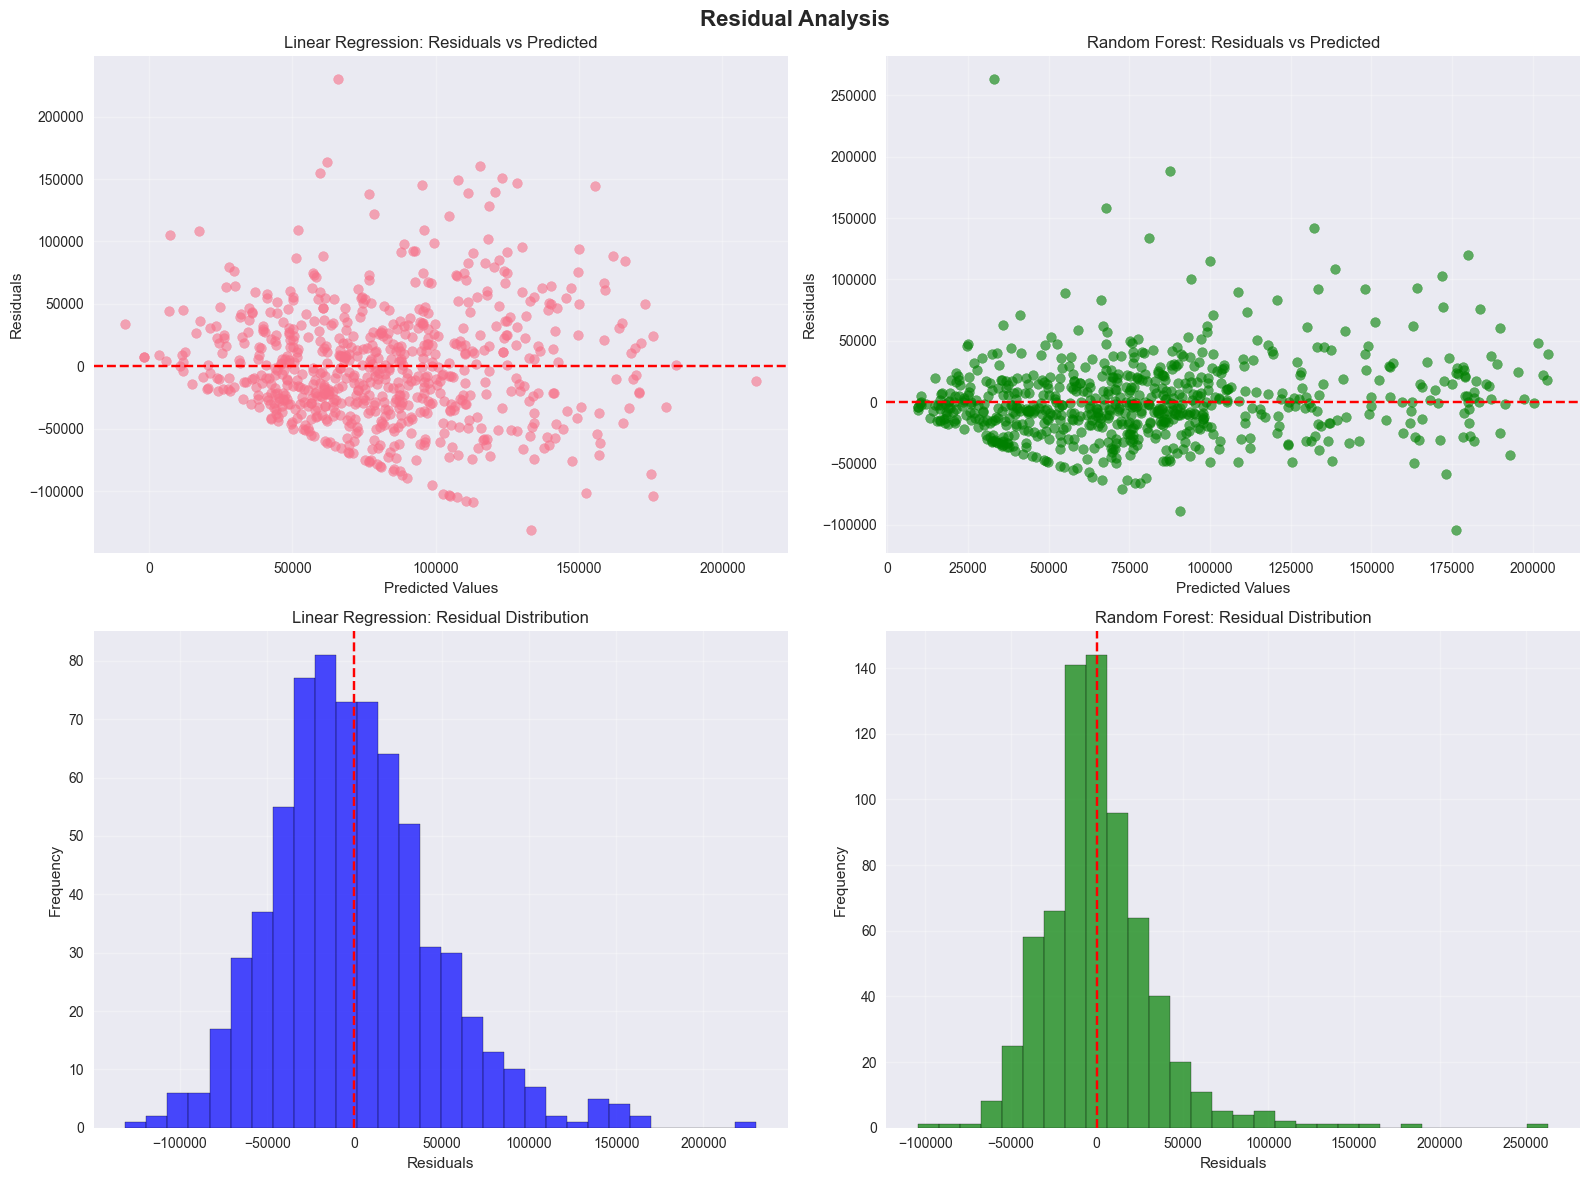

In [97]:
# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Residual Analysis', fontsize=16, fontweight='bold')

# Linear Regression residuals
axes[0, 0].scatter(y_pred_lr, lr_errors, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Linear Regression: Residuals vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Random Forest residuals
axes[0, 1].scatter(y_pred_rf, rf_errors, alpha=0.6, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Random Forest: Residuals vs Predicted')
axes[0, 1].grid(True, alpha=0.3)

# Histogram of residuals
axes[1, 0].hist(lr_errors, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Linear Regression: Residual Distribution')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(rf_errors, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Random Forest: Residual Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 ## Error Distribution Analysis

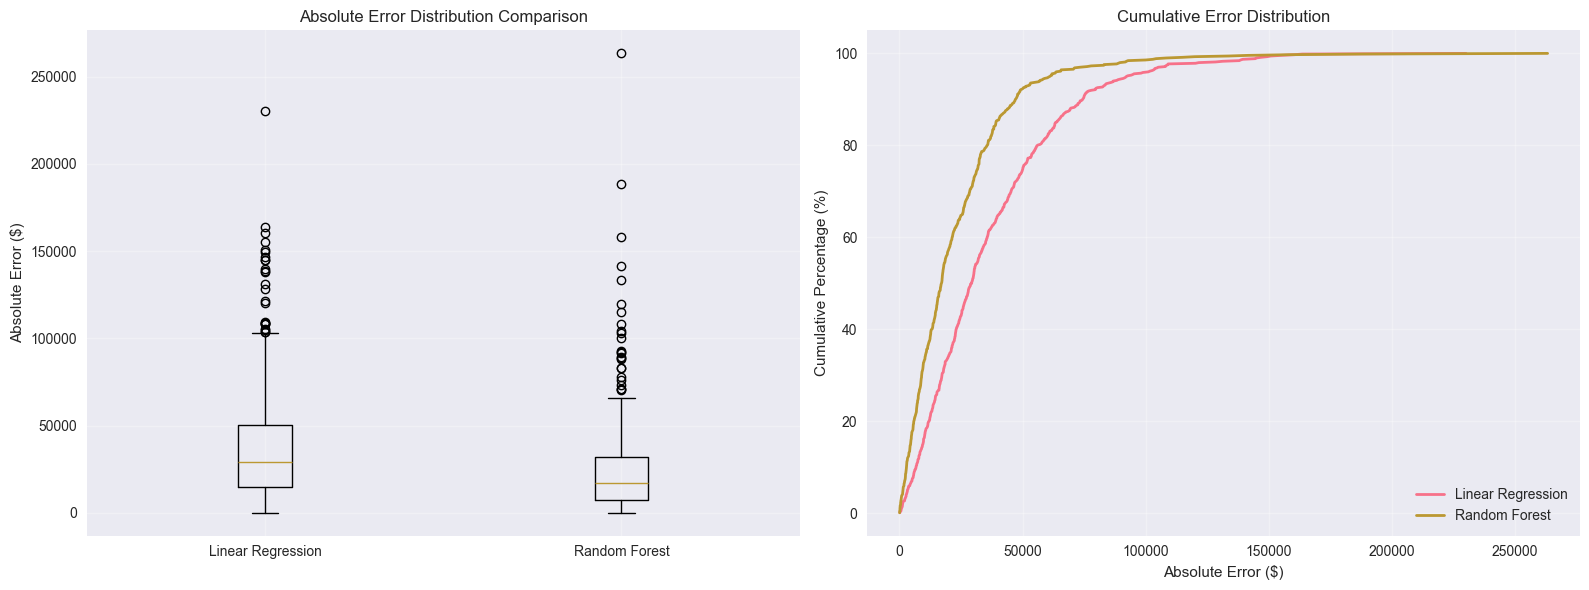


ERROR PERCENTILE ANALYSIS
Percentile   Linear Reg ($)  Random Forest ($)
---------------------------------------------
25th          14,565       7,595
50th          29,336       17,059
75th          50,140       31,812
90th          74,387       47,114
95th          92,271       61,101
99th          144,937       108,531


In [98]:
# Absolute error analysis
lr_abs_errors = np.abs(lr_errors)
rf_abs_errors = np.abs(rf_errors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot comparison
ax1.boxplot([lr_abs_errors, rf_abs_errors], labels=['Linear Regression', 'Random Forest'])
ax1.set_ylabel('Absolute Error ($)')
ax1.set_title('Absolute Error Distribution Comparison')
ax1.grid(True, alpha=0.3)

# Cumulative error distribution
lr_sorted_errors = np.sort(lr_abs_errors)
rf_sorted_errors = np.sort(rf_abs_errors)
lr_cumulative = np.arange(1, len(lr_sorted_errors) + 1) / len(lr_sorted_errors) * 100
rf_cumulative = np.arange(1, len(rf_sorted_errors) + 1) / len(rf_sorted_errors) * 100

ax2.plot(lr_sorted_errors, lr_cumulative, label='Linear Regression', linewidth=2)
ax2.plot(rf_sorted_errors, rf_cumulative, label='Random Forest', linewidth=2)
ax2.set_xlabel('Absolute Error ($)')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_title('Cumulative Error Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error percentiles
print("\n" + "="*60)
print("ERROR PERCENTILE ANALYSIS")
print("="*60)
percentiles = [25, 50, 75, 90, 95, 99]
print(f"{'Percentile':<12} {'Linear Reg ($)':<15} {'Random Forest ($)':<15}")
print("-" * 45)
for p in percentiles:
    lr_p = np.percentile(lr_abs_errors, p)
    rf_p = np.percentile(rf_abs_errors, p)
    print(f"{p}th{'':<9} {lr_p:,.0f}{'':<6} {rf_p:,.0f}")
print("="*60)


 ## Additional Accuracy Analysis

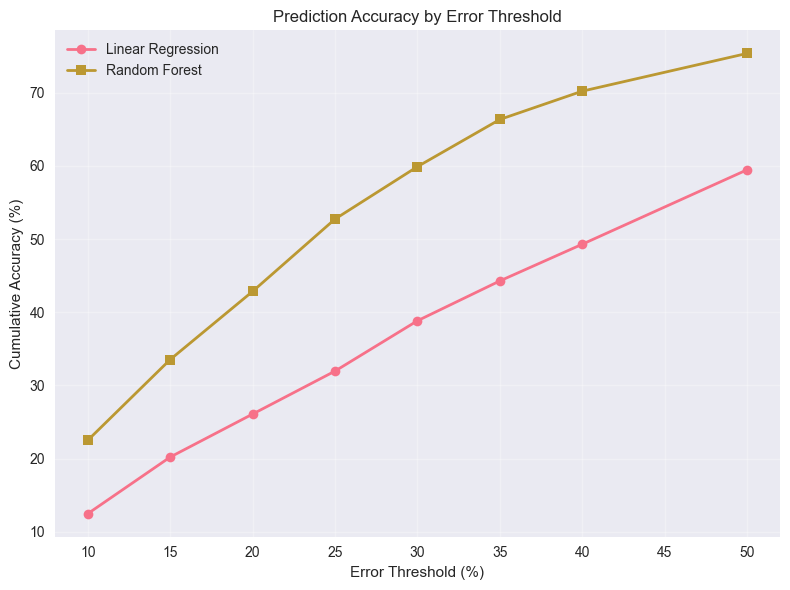

In [99]:
# Create accuracy band visualization
fig, ax1 = plt.subplots(figsize=(8, 6))

# Accuracy bands for both models
error_bands = [10, 15, 20, 25, 30, 35, 40, 50]
lr_individual_errors = np.abs((y_test - y_pred_lr) / y_test) * 100
rf_individual_errors = np.abs((y_test - y_pred_rf) / y_test) * 100

lr_accuracy = []
rf_accuracy = []

for band in error_bands:
    lr_acc = (lr_individual_errors <= band).sum() / len(lr_individual_errors) * 100
    rf_acc = (rf_individual_errors <= band).sum() / len(rf_individual_errors) * 100
    lr_accuracy.append(lr_acc)
    rf_accuracy.append(rf_acc)

ax1.plot(error_bands, lr_accuracy, marker='o', linewidth=2, label='Linear Regression')
ax1.plot(error_bands, rf_accuracy, marker='s', linewidth=2, label='Random Forest')
ax1.set_xlabel('Error Threshold (%)')
ax1.set_ylabel('Cumulative Accuracy (%)')
ax1.set_title('Prediction Accuracy by Error Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



 ## Model Performance Summary

In [100]:
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)

print(f"\nDataset Information:")
print(f"• Total samples: {len(df):,}")
print(f"• Training samples: {len(y_train):,} ({len(y_train)/len(df)*100:.1f}%)")
print(f"• Test samples: {len(y_test):,} ({len(y_test)/len(df)*100:.1f}%)")
print(f"• Salary range: ${y_test.min():,.0f} - ${y_test.max():,.0f}")
print(f"• Mean salary: ${y_test.mean():,.0f}")

print(f"\nBest Performing Model: Random Forest")
print(f"• RMSE: ${rf_metrics['RMSE']:,.0f} ({rmse_improvement:.1f}% better than LR)")
print(f"• MAE: ${rf_metrics['MAE']:,.0f} ({mae_improvement:.1f}% better than LR)")
print(f"• R² Score: {rf_metrics['R²']:.3f} ({r2_improvement:.1f}% better than LR)")
print(f"• Median APE: {rf_metrics['Median APE (%)']:.1f}% (robust percentage error)")
print(f"• {rf_metrics['Within 20% (%)']:.1f}% of predictions within 20% error")
print(f"• {rf_metrics['Within 30% (%)']:.1f}% of predictions within 30% error")
print(f"• Explains {rf_metrics['R²']*100:.1f}% of salary variance")

print("="*80)



MODEL PERFORMANCE SUMMARY

Dataset Information:
• Total samples: 13,956
• Training samples: 13,258 (95.0%)
• Test samples: 698 (5.0%)
• Salary range: $1 - $300,000
• Mean salary: $81,762

Best Performing Model: Random Forest
• RMSE: $32,861 (30.3% better than LR)
• MAE: $22,906 (37.1% better than LR)
• R² Score: 0.693 (87.8% better than LR)
• Median APE: 23.6% (robust percentage error)
• 42.8% of predictions within 20% error
• 59.9% of predictions within 30% error
• Explains 69.3% of salary variance
